In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
inventory_df = pd.read_csv("../data/processed/final_inventory_recommendation.csv")

inventory_df.head()

,sku_id,avg_actual_demand,avg_predicted_demand,demand_std,current_stock,selling_price,supplier_id,lead_time_days,avg_lead_time,lead_time_variability,safety_stock,reorder_point,inventory_status,annual_consumptino_value,annual_consumption_value,cumulative_value,cumulative_percentage,ABC_Class,cv,XYZ_Class,ABC_XYZ,calculated_safety_stock,calculated_reorder_point,holding_cost,annual_demand,EOQ,days_of_inventory,inventory_gap,risk_score,risk_level,recommendation
0,38,34.043478,34.133961,7.132127,1055,1831.211806,1,11.0,11.0,4.0,308,727,Overstock,2.281488e+07,2.281488e+07,2.281488e+07,6.107329,A,0.209501,X,AX,39.030070,414.503643,366.242361,12458.895809,184.440160,30.907635,640.496357,28.528507,High,Reduce Inventory
1,29,31.264214,31.293951,7.871904,494,1702.419699,5,5.0,5.0,2.0,128,304,Overstock,1.944554e+07,1.944554e+07,4.226041e+07,11.312717,A,0.251786,Y,AY,29.043485,185.513239,340.483940,11422.292066,183.159021,15.785798,308.486761,15.743808,Medium,Reduce Inventory
2,24,23.277592,23.430942,5.488842,776,2119.237224,2,10.0,10.0,2.0,322,593,Overstock,1.812434e+07,1.812434e+07,6.038475e+07,16.164434,A,0.235799,X,AX,28.639448,262.948870,423.847445,8552.293907,142.048458,33.118600,513.051130,10.977683,Low,Reduce Inventory
3,39,29.729097,30.079778,5.737273,438,1638.972642,7,5.0,5.0,4.0,173,341,Overstock,1.799448e+07,1.799448e+07,7.837923e+07,20.981387,A,0.192985,X,AX,21.167737,171.566630,327.794528,10979.119140,183.013404,14.561277,266.433370,22.949091,Medium,Reduce Inventory
4,12,37.518395,37.570501,6.278398,710,1206.858395,8,7.0,7.0,4.0,352,641,Overstock,1.654993e+07,1.654993e+07,9.492916e+07,25.411648,A,0.167342,X,AX,27.408283,290.401792,241.371679,13713.232987,238.356375,18.897805,419.598208,25.113593,High,Reduce Inventory


In [3]:
inventory_df.shape

(40, 31)

In [4]:
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   sku_id                    40 non-null     int64  
 1   avg_actual_demand         40 non-null     float64
 2   avg_predicted_demand      40 non-null     float64
 3   demand_std                40 non-null     float64
 4   current_stock             40 non-null     int64  
 5   selling_price             40 non-null     float64
 6   supplier_id               40 non-null     int64  
 7   lead_time_days            40 non-null     float64
 8   avg_lead_time             40 non-null     float64
 9   lead_time_variability     40 non-null     float64
 10  safety_stock              40 non-null     int64  
 11  reorder_point             40 non-null     int64  
 12  inventory_status          40 non-null     object 
 13  annual_consumptino_value  40 non-null     float64
 14  annual_consu

In [5]:
inventory_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sku_id,40.0,1.950000e+01,1.169045e+01,0.000000e+00,9.750000e+00,1.950000e+01,2.925000e+01,3.900000e+01
avg_actual_demand,40.0,2.966622e+01,3.892680e+00,2.320736e+01,2.700418e+01,2.962207e+01,3.148662e+01,3.770903e+01
avg_predicted_demand,40.0,2.972126e+01,3.845683e+00,2.339148e+01,2.704325e+01,2.976298e+01,3.150416e+01,3.757050e+01
demand_std,40.0,6.611504e+00,7.494682e-01,5.367766e+00,6.046377e+00,6.651204e+00,7.143648e+00,8.193058e+00
current_stock,40.0,6.113750e+02,3.109954e+02,1.640000e+02,3.687500e+02,5.350000e+02,8.075000e+02,1.166000e+03
selling_price,40.0,8.591916e+02,4.803956e+02,1.963713e+02,5.029874e+02,7.930489e+02,1.153043e+03,2.119237e+03
supplier_id,40.0,4.275000e+00,2.459805e+00,0.000000e+00,2.000000e+00,4.000000e+00,6.000000e+00,9.000000e+00
lead_time_days,40.0,7.425000e+00,3.463269e+00,3.000000e+00,5.000000e+00,6.000000e+00,1.000000e+01,1.300000e+01
avg_lead_time,40.0,7.425000e+00,3.463269e+00,3.000000e+00,5.000000e+00,6.000000e+00,1.000000e+01,1.300000e+01
lead_time_variability,40.0,3.000000e+00,1.012739e+00,2.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00


In [6]:
numeric_cols = [
    "avg_actual_demand",
    "avg_predicted_demand",
    "current_stock",
    "EOQ",
    "calculated_reorder_point",
    "calculated_safety_stock"
]

(inventory_df[numeric_cols] < 0).sum()

avg_actual_demand           0
avg_predicted_demand        0
current_stock               0
EOQ                         0
calculated_reorder_point    0
calculated_safety_stock     0
dtype: int64

In [7]:
inventory_df["inventory_status"].value_counts()

inventory_status
Overstock    22
Optimal      18
Name: count, dtype: int64

In [8]:
inventory_df["recommendation"].value_counts()

recommendation
Reduce Inventory          22
Maintain Current Stock    18
Name: count, dtype: int64

In [9]:
inventory_df["EOQ"].describe()

count     40.000000
mean     284.159205
std       88.082230
min      142.048458
25%      218.898051
50%      276.195171
75%      332.176421
max      529.831246
Name: EOQ, dtype: float64

In [10]:
inventory_df["days_of_inventory"].describe()

count    40.000000
mean     20.816541
std      10.684770
min       5.961964
25%      12.625101
50%      17.849895
75%      30.173501
max      42.458046
Name: days_of_inventory, dtype: float64

In [11]:
inventory_df[
    inventory_df["current_stock"] <
    inventory_df["calculated_reorder_point"]
][[
    "sku_id",
    "current_stock",
    "calculated_reorder_point",
    "recommendation"
]].head(20)



,sku_id,current_stock,calculated_reorder_point,recommendation


# OverStock Logic

In [12]:
inventory_df[
    inventory_df["current_stock"] >
    inventory_df["EOQ"] * 2
][[
    "sku_id",
    "current_stock",
    "EOQ",
    "recommendation"
]].head(20)

,sku_id,current_stock,EOQ,recommendation
0,38,1055,184.440160,Reduce Inventory
1,29,494,183.159021,Reduce Inventory
2,24,776,142.048458,Reduce Inventory
3,39,438,183.013404,Reduce Inventory
4,12,710,238.356375,Reduce Inventory
6,5,496,182.339437,Reduce Inventory
8,37,536,255.125059,Reduce Inventory
9,14,555,203.120458,Reduce Inventory
11,13,1143,208.957116,Reduce Inventory
12,27,695,230.721141,Reduce Inventory


In [13]:
inventory_df["ABC_Class"].value_counts(normalize=True) * 100

ABC_Class
A    57.5
B    25.0
C    17.5
Name: proportion, dtype: float64

# Forest vs actual






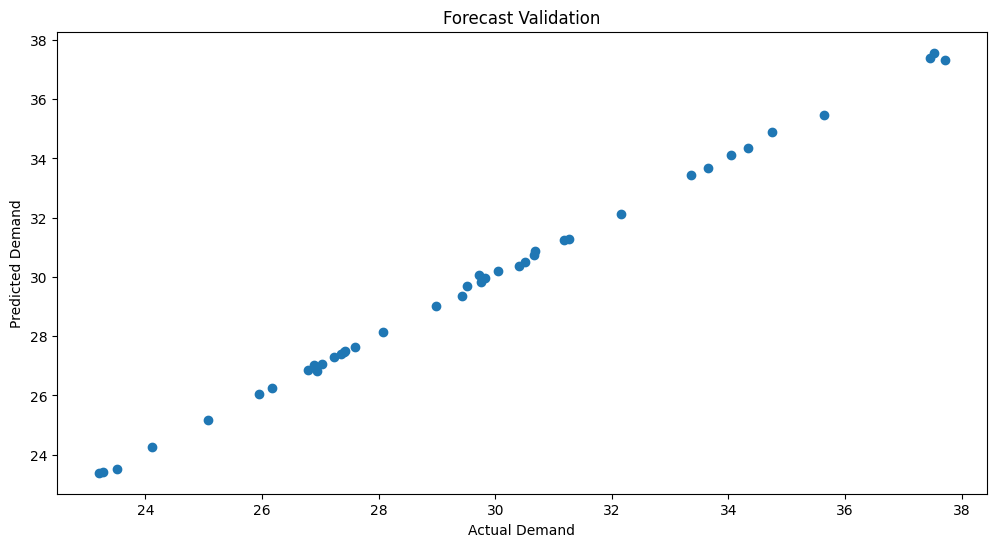

In [14]:
plt.figure(figsize=(12,6))

plt.scatter(
    inventory_df["avg_actual_demand"],
    inventory_df["avg_predicted_demand"]
)

plt.xlabel("Actual Demand")

plt.ylabel("Predicted Demand")

plt.title("Forecast Validation")

plt.show()

In [15]:
print("Total SKUs:", len(inventory_df))

print("Average Forecast Demand:",
      inventory_df["avg_predicted_demand"].mean())

print("Average Current Stock:",
      inventory_df["current_stock"].mean())

print("Average EOQ:",
      inventory_df["EOQ"].mean())

print("Reorder SKUs:",
      (inventory_df["inventory_status"]=="Reorder").sum())

print("Overstock SKUs:",
      (inventory_df["inventory_status"]=="Overstock").sum())

Total SKUs: 40
Average Forecast Demand: 29.72126370576923
Average Current Stock: 611.375
Average EOQ: 284.1592054423451
Reorder SKUs: 0
Overstock SKUs: 22
